In [1]:
import matplotlib.pyplot as plt
import numpy as np
#from netCDF4 import Dataset
from matplotlib import cm
import xarray as xr
import pandas as pd
#import datetime
#from xgrads import CtlDescriptor, open_CtlDataset, open_mfdataset
from shapely import wkt, plotting, Point, buffer, geometry
import os
import cmweather
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.tsa.stattools import ccf
from matplotlib.gridspec import GridSpec


In [5]:
d = {}
d_full = {}
d_full2 = {}
d3 = {}

path = '/data/keeling/a/melinda3/gpm/data_dir/'
path2 = '/data/keeling/a/melinda3/meso/pres_perts_dir/'


lower_shear = [6, 8, 10]
upper_shear = [29, 31, 33, 35]

for li in lower_shear:
    for ui in upper_shear:
        if (ui == 31):
            continue
        elif (ui == 29) & (li == 8):
            hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
            file_in = pd.read_csv(path+hash)
            file_in = file_in.replace(-9999, np.nan)
            d_full["area{0}_{1}_dss".format(li, ui)] = file_in
            
            hash2 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all_test.csv'
            file_in2 = pd.read_csv(path2+hash2)
            file_in2 = file_in2.replace(-9999, np.nan)
            d_full2["area{0}_{1}_dss".format(li, ui)] = file_in2
            
        else:
            hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
            file_in = pd.read_csv(path+hash)
            file_in = file_in.replace(-9999, np.nan)
            d_full["area{0}_{1}_dss".format(li, ui)] = file_in

            hash2 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all.csv'
            file_in2 = pd.read_csv(path2+hash2)
            file_in2 = file_in2.replace(-9999, np.nan)
            d_full2["area{0}_{1}_dss".format(li, ui)] = file_in2



d = d_full
d3 = d_full2

In [6]:
#Process the data to get OTD at every time for the runs of interest
a629 = d['area6_29_dss']
a633 = d['area6_33_dss']
a635 = d['area6_35_dss']

a829 = d['area8_29_dss']
a833 = d['area8_33_dss']
a835 = d['area8_35_dss']

a1029 = d['area10_29_dss']
a1033 = d['area10_33_dss']
a1035 = d['area10_35_dss']


In [7]:
#Add OTD to each of the groups to make sure we can loop through it as well
for key in d3:
    current_df = d3[key]
    current_df['otd'] = current_df.groupby("time")['hght'].transform('max')-13.375

area6_29_dss
area6_33_dss
area6_35_dss
area8_29_dss
area8_33_dss
area8_35_dss
area10_29_dss
area10_33_dss
area10_35_dss


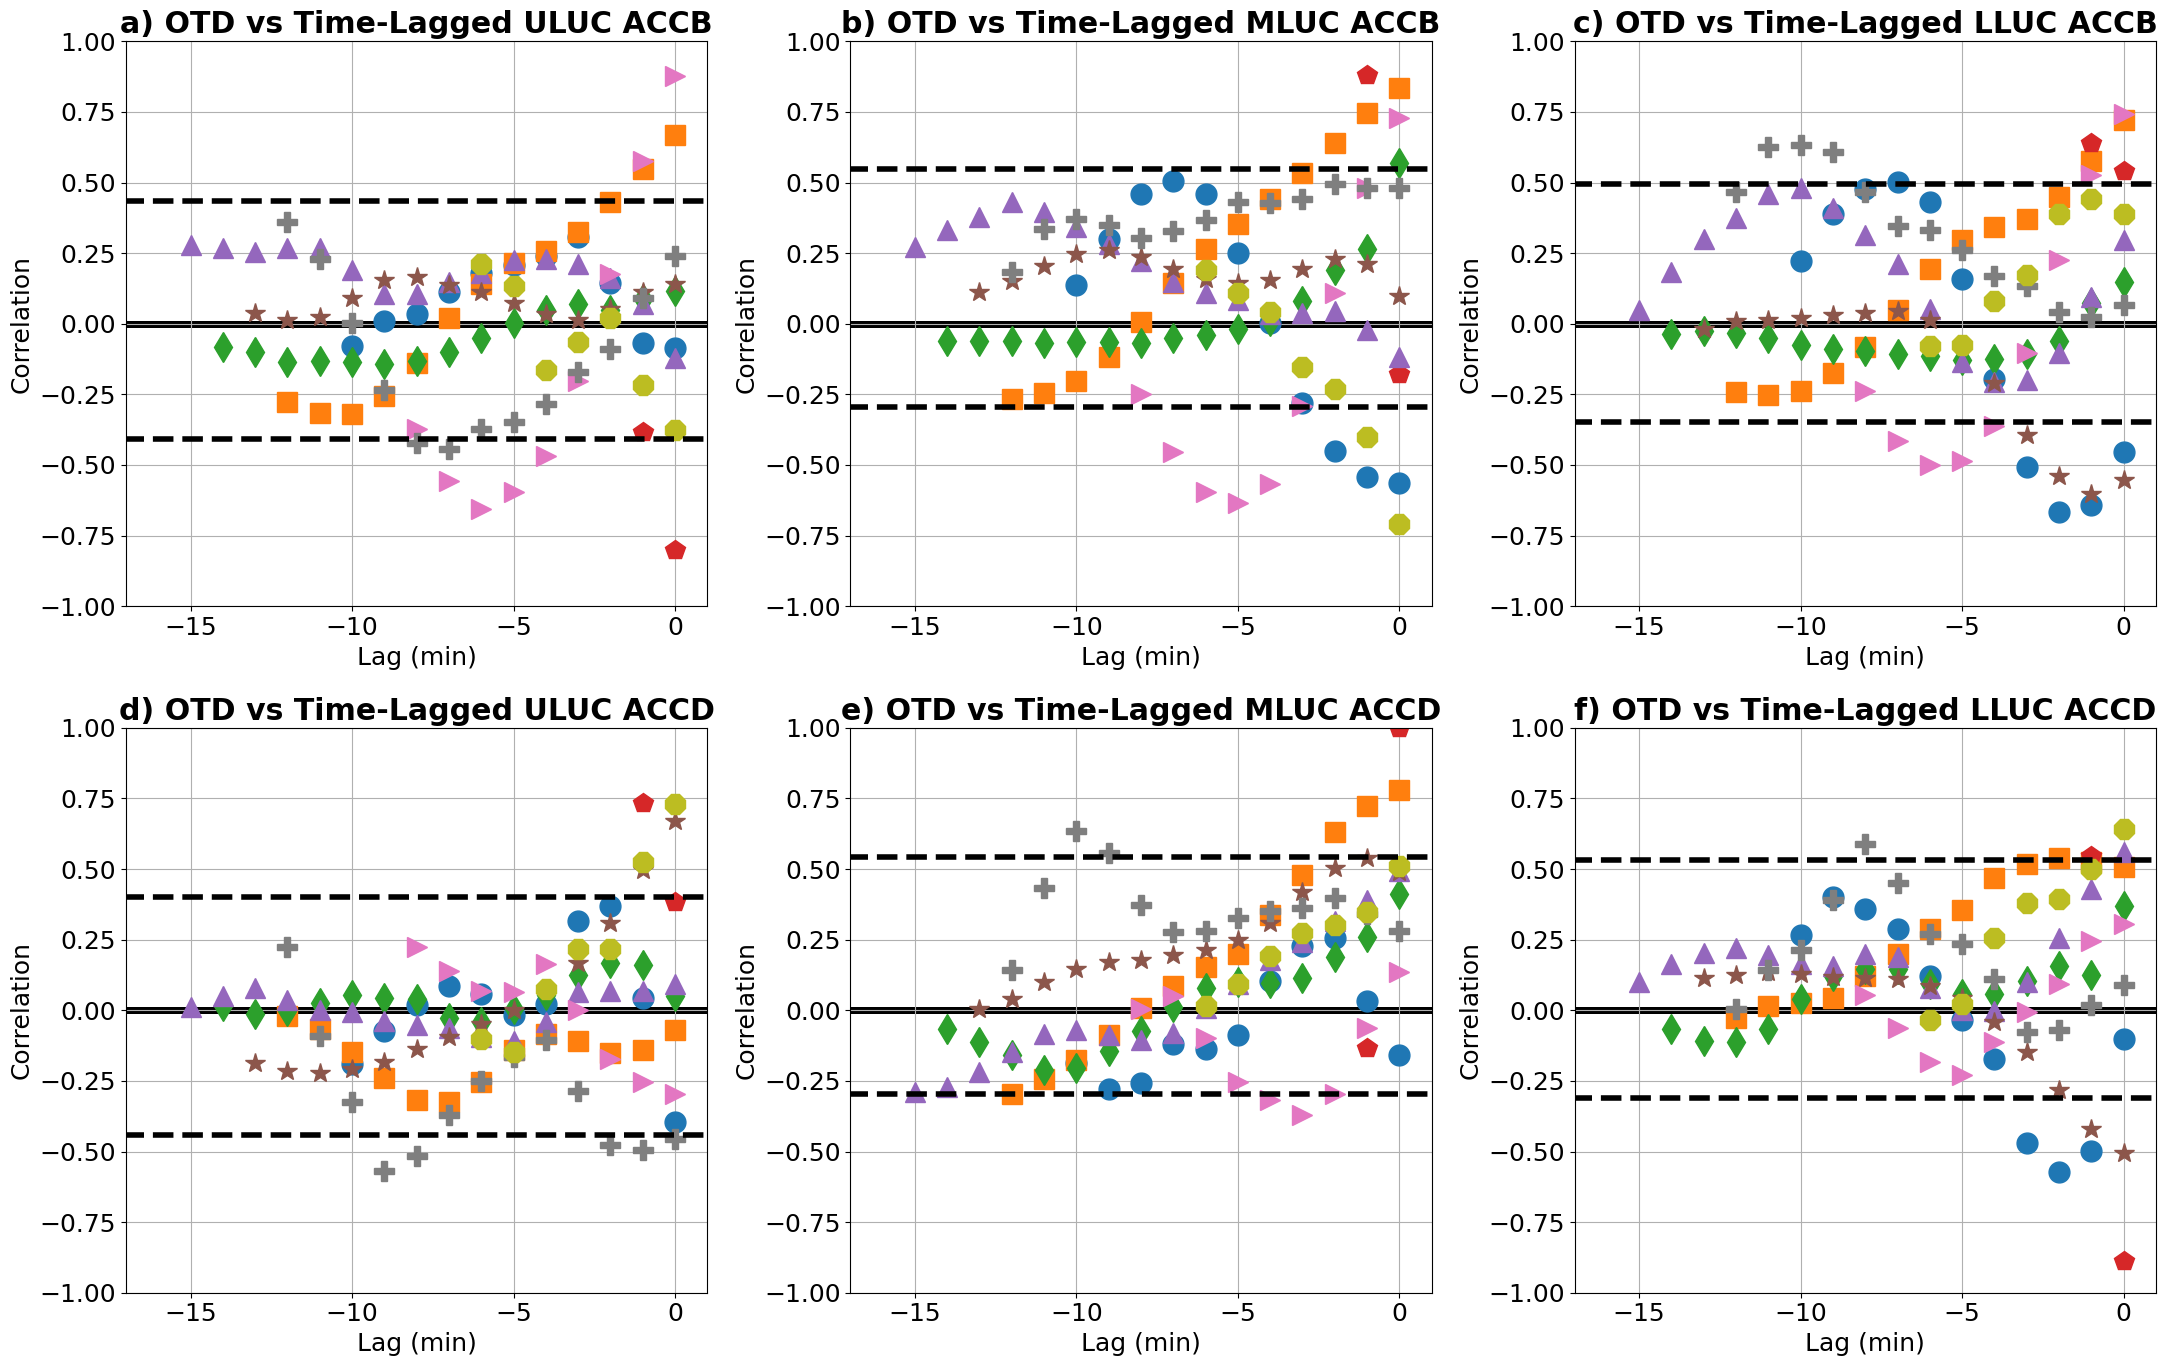

In [9]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (22, 14))
markers = ['o', 's', 'd', 'p', '^', '*',  '>', 'P', '8']
key_labels = ['629', '633', '635', '829', '833', '835', '1029', '1033', '1035']
key_sub = ['area10_31_dss']
n = 0
tl_lower = np.full((len(key_labels), 20), np.nan)
tl_upper = np.full((len(key_labels), 20), np.nan)
tc_lower = np.full((len(key_labels), 20), np.nan)
tc_upper = np.full((len(key_labels), 20), np.nan) 
tr_lower = np.full((len(key_labels), 20), np.nan)
tr_upper = np.full((len(key_labels), 20), np.nan) 
ll_lower = np.full((len(key_labels), 20), np.nan)
ll_upper = np.full((len(key_labels), 20), np.nan) 
lc_lower = np.full((len(key_labels), 20), np.nan)
lc_upper = np.full((len(key_labels), 20), np.nan) 
lr_lower = np.full((len(key_labels), 20), np.nan)
lr_upper = np.full((len(key_labels), 20), np.nan) 
for key in d3:
    print(key)
    mark_curr = markers[n]
    d_curr = d[key]
    df_curr = d3[key]
    t_split = d_curr['time_split'].iloc[0]
    df_curr = df_curr[df_curr.time > t_split]
    df_low = df_curr[(df_curr.hght > 3.8) & (df_curr.hght < 4.1)].set_index(['time'])
    df_mid = df_curr[(df_curr.hght > 5.9) & (df_curr.hght < 6.2)].set_index(['time'])
    df_upper = df_curr[(df_curr.hght > 9.9) & (df_curr.hght < 10.2)].set_index(['time'])
    df_ot = df_curr[(df_curr.hght > 13.3) & (df_curr.hght < 13.4)].set_index(['time'])
    time_min = min(df_low['accbavg_over_polygon'].index)
    df_low = df_low[df_low.index >= time_min]
    df_mid = df_mid[df_mid.index >= time_min]
    df_upper = df_upper[df_upper.index >= time_min]
    df_ot = df_ot[df_ot.index >= time_min]
    f, ccf_xy, cint  = plot_ccf(df_upper['otd'].values, df_upper['accbavg_over_polygon'].values,  alpha = 0.05, ax = axes[0,0], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[0,0].set_title('a) OTD vs Time-Lagged ULUC ACCB',weight = 'bold')
    axes[0,0].set_xlabel('Lag (min)')
    axes[0,0].set_ylabel('Correlation')
    axes[0,0].grid(True)
    axes[0,0].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[0,0].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    tl_lower[n, 0:len(lower_bounds)] = lower_bounds
    tl_upper[n, 0:len(upper_bounds)] = upper_bounds 

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_mid['accbavg_over_polygon'].values, alpha = 0.05,ax = axes[0,1], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[0,1].set_title(r'b) OTD vs Time-Lagged MLUC ACCB',weight = 'bold')
    axes[0,1].set_xlabel('Lag (min)')
    axes[0,1].set_ylabel('Correlation')
    axes[0,1].grid(True)
    axes[0,1].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[0,1].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    tc_lower[n, 0:len(lower_bounds)] = lower_bounds
    tc_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_low['accbavg_over_polygon'].values, ax = axes[0,2], alpha = 0.05,use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[0,2].set_title(r'c) OTD vs Time-Lagged LLUC ACCB',weight = 'bold')
    axes[0,2].set_xlabel('Lag (min)')
    axes[0,2].set_ylabel('Correlation')
    axes[0,2].grid(True)
    axes[0,2].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[0,2].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    tr_lower[n, 0:len(lower_bounds)] = lower_bounds
    tr_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_upper['accdavg_over_polygon'].values, alpha = 0.05,ax = axes[1,0], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[1,0].set_title(r'd) OTD vs Time-Lagged ULUC ACCD',weight = 'bold')
    axes[1,0].set_xlabel('Lag (min)')
    axes[1,0].set_ylabel('Correlation')
    axes[1,0].grid(True)
    axes[1,0].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[1,0].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    ll_lower[n, 0:len(lower_bounds)] = lower_bounds
    ll_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_mid['accdavg_over_polygon'].values, alpha = 0.05,ax = axes[1,1], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[1,1].set_title(r'e) OTD vs Time-Lagged MLUC ACCD',weight = 'bold')
    axes[1,1].set_xlabel('Lag (min)')
    axes[1,1].set_ylabel('Correlation')
    axes[1,1].grid(True)
    axes[1,1].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[1,1].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    lc_lower[n, 0:len(lower_bounds)] = lower_bounds
    lc_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_low['accdavg_over_polygon'].values, alpha = 0.05, ax = axes[1,2], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[1,2].set_title(r'f) OTD vs Time-Lagged LLUC ACCD', weight = 'bold')
    axes[1,2].set_xlabel('Lag (min)')
    axes[1,2].set_ylabel('Correlation')
    axes[1,2].grid(True)
    axes[1,2].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[1,2].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    lr_lower[n, 0:len(lower_bounds)] = lower_bounds
    lr_upper[n, 0:len(upper_bounds)] = upper_bounds
    n+=1
    
#Add a legend

#Calculate the average confidence intervals and add them to their respective plots
lower_tl = np.nanmean(tl_lower)
upper_tl = np.nanmean(tl_upper)
lower_tc = np.nanmean(tc_lower)
upper_tc = np.nanmean(tc_upper)
lower_tr = np.nanmean(tr_lower)
upper_tr = np.nanmean(tr_upper)
lower_ll = np.nanmean(ll_lower)
upper_ll = np.nanmean(ll_upper)
lower_lc = np.nanmean(lc_lower)
upper_lc = np.nanmean(lc_upper)
lower_lr = np.nanmean(lr_lower)
upper_lr = np.nanmean(lr_upper)
axes[0,0].hlines(lower_tl, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[0,0].hlines(upper_tl, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[0,1].hlines(lower_tc, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[0,1].hlines(upper_tc, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[0,2].hlines(lower_tr, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[0,2].hlines(upper_tr, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[1,0].hlines(lower_ll, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[1,0].hlines(upper_ll, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[1,1].hlines(lower_lc, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[1,1].hlines(upper_lc, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[1,2].hlines(lower_lr, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)
axes[1,2].hlines(upper_lr, -18, 2, ls = '--', color = 'k', zorder = 2, lw = 4)

plt.tight_layout()

area6_29_dss
area6_33_dss
area6_35_dss
area8_29_dss
area8_33_dss
area8_35_dss
area10_29_dss
area10_33_dss
area10_35_dss


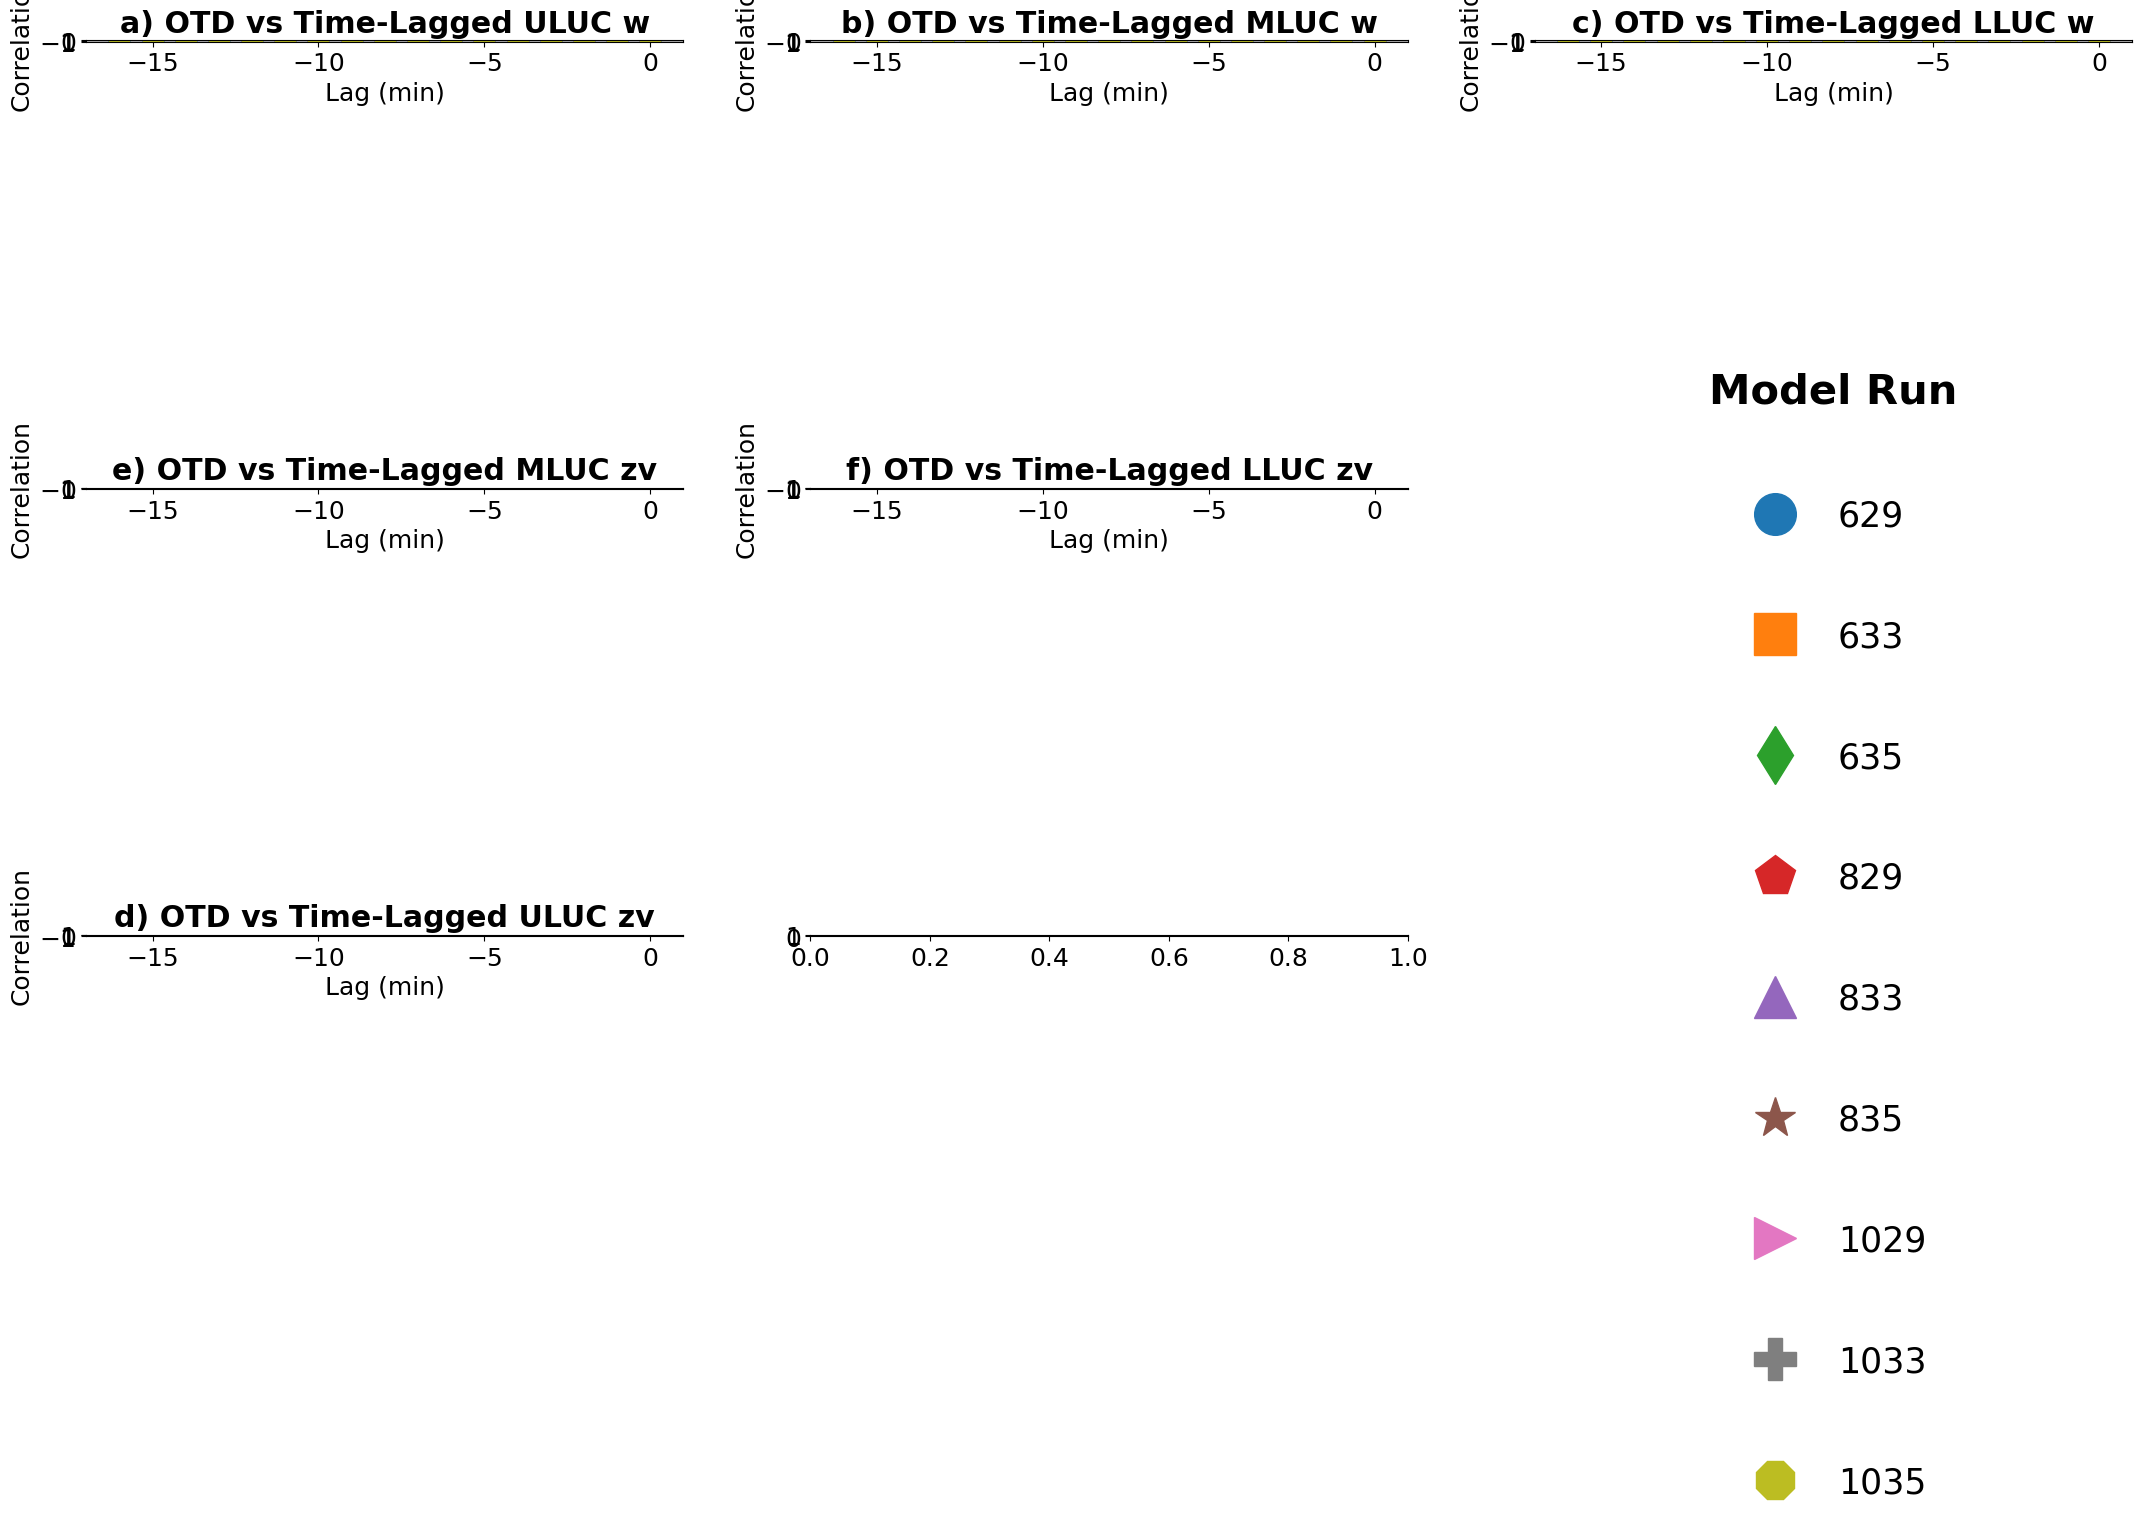

In [10]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (22, 14))
markers = ['o', 's', 'd', 'p', '^', '*',  '>', 'P', '8']
key_labels = ['629', '633', '635', '829', '833', '835', '1029', '1033', '1035']
key_sub = ['area10_31_dss']
n = 0
tl_lower = np.full((len(key_labels), 20), np.nan)
tl_upper = np.full((len(key_labels), 20), np.nan)
tc_lower = np.full((len(key_labels), 20), np.nan)
tc_upper = np.full((len(key_labels), 20), np.nan) 
tr_lower = np.full((len(key_labels), 20), np.nan)
tr_upper = np.full((len(key_labels), 20), np.nan) 
ll_lower = np.full((len(key_labels), 20), np.nan)
ll_upper = np.full((len(key_labels), 20), np.nan) 
lc_lower = np.full((len(key_labels), 20), np.nan)
lc_upper = np.full((len(key_labels), 20), np.nan) 
lr_lower = np.full((len(key_labels), 20), np.nan)
lr_upper = np.full((len(key_labels), 20), np.nan) 
for key in d3:
    print(key)
    mark_curr = markers[n]
    df_curr = d3[key]
    df_low = df_curr[(df_curr.hght > 3.8) & (df_curr.hght < 4.1)].set_index(['time'])
    df_mid = df_curr[(df_curr.hght > 5.9) & (df_curr.hght < 6.2)].set_index(['time'])
    df_upper = df_curr[(df_curr.hght > 9.9) & (df_curr.hght < 10.2)].set_index(['time'])
    df_ot = df_curr[(df_curr.hght > 13.3) & (df_curr.hght < 13.4)].set_index(['time'])
    time_min = min(df_low['accbavg_over_polygon'].index)
    df_low = df_low[df_low.index >= time_min]
    df_mid = df_mid[df_mid.index >= time_min]
    df_upper = df_upper[df_upper.index >= time_min]
    df_ot = df_ot[df_ot.index >= time_min]
    f, ccf_xy, cint  = plot_ccf(df_upper['otd'].values, df_upper['accbavg_over_polygon'].values,  alpha = 0.05, ax = axes[0,0], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr, label = key_labels[n])
    axes[0,0].set_title('a) OTD vs Time-Lagged ULUC w',weight = 'bold')
    axes[0,0].set_xlabel('Lag (min)')
    axes[0,0].set_ylabel('Correlation')
    axes[0,0].grid(True)
    axes[0,0].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[0,0].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    tl_lower[n, 0:len(lower_bounds)] = lower_bounds
    tl_upper[n, 0:len(upper_bounds)] = upper_bounds 

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_mid['accbavg_over_polygon'].values, alpha = 0.05,ax = axes[0,1], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[0,1].set_title(r'b) OTD vs Time-Lagged MLUC w',weight = 'bold')
    axes[0,1].set_xlabel('Lag (min)')
    axes[0,1].set_ylabel('Correlation')
    axes[0,1].grid(True)
    axes[0,1].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[0,1].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    tc_lower[n, 0:len(lower_bounds)] = lower_bounds
    tc_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_low['accbavg_over_polygon'].values, ax = axes[0,2], alpha = 0.05,use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[0,2].set_title(r'c) OTD vs Time-Lagged LLUC w',weight = 'bold')
    axes[0,2].set_xlabel('Lag (min)')
    axes[0,2].set_ylabel('Correlation')
    axes[0,2].grid(True)
    axes[0,2].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[0,2].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    tr_lower[n, 0:len(lower_bounds)] = lower_bounds
    tr_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_upper['accdavg_over_polygon'].values, alpha = 0.05,ax = axes[2,0], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[2,0].set_title(r'd) OTD vs Time-Lagged ULUC zv',weight = 'bold')
    axes[2,0].set_xlabel('Lag (min)')
    axes[2,0].set_ylabel('Correlation')
    axes[2,0].grid(True)
    axes[2,0].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[2,0].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    ll_lower[n, 0:len(lower_bounds)] = lower_bounds
    ll_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_mid['accdavg_over_polygon'].values, alpha = 0.05,ax = axes[1,0], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[1,0].set_title(r'e) OTD vs Time-Lagged MLUC zv',weight = 'bold')
    axes[1,0].set_xlabel('Lag (min)')
    axes[1,0].set_ylabel('Correlation')
    axes[1,0].grid(True)
    axes[1,0].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[1,0].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    lc_lower[n, 0:len(lower_bounds)] = lower_bounds
    lc_upper[n, 0:len(upper_bounds)] = upper_bounds

    f, ccf_xy, cint = plot_ccf(df_upper['otd'].values, df_low['accdavg_over_polygon'].values, alpha = 0.05, ax = axes[1,1], use_vlines = False, markersize = 15, negative_lags = True,\
             marker = mark_curr)
    axes[1,1].set_title(r'f) OTD vs Time-Lagged LLUC zv', weight = 'bold')
    axes[1,1].set_xlabel('Lag (min)')
    axes[1,1].set_ylabel('Correlation')
    axes[1,1].grid(True)
    axes[1,1].axhline(0, -20, 2, color = 'k', lw = 5, zorder = 0)
    axes[1,1].set_xlim(-17, 1)
    lower_bounds = cint[:,0]
    upper_bounds = cint[:,1]
    lr_lower[n, 0:len(lower_bounds)] = lower_bounds
    lr_upper[n, 0:len(upper_bounds)] = upper_bounds
    n+=1
    
#Add a legend
handles, labels = axes[0,0].get_legend_handles_labels()
l_prob = {'weight':'bold'}
leg = axes[2,2].legend(handles, labels, loc = 'center', frameon = False, fontsize = 25, ncol = 1, labelspacing = 2.5,\
                      markerscale = 2.0)
leg.set_title('Model Run', prop={'size':30, 'weight':'bold'})
axes[2,2].set_xticklabels([])
axes[2,2].set_yticklabels([])
axes[2,2].axis('off')
axes[1,2].set_xticklabels([])
axes[1,2].set_yticklabels([])
axes[1,2].axis('off')


plt.tight_layout()

In [15]:
%history -g -f filename.py